# Burger King: Fat (g) vs Calories

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.linear_model

In [14]:
# Load the data
burger_king = pd.read_csv("burger-king-menu.csv")

In [15]:
# Explain the data
print(burger_king.shape)
print(burger_king.columns)
print(burger_king["Category"].value_counts())
burger_king.info()
burger_king.describe()

(77, 14)
Index(['Item', 'Category', 'Calories', 'Fat Calories', 'Fat (g)',
       'Saturated Fat (g)', 'Trans Fat (g)', 'Cholesterol (mg)', 'Sodium (mg)',
       'Total Carb (g)', 'Dietary Fiber (g)', 'Sugars (g)', 'Protein (g)',
       'Weight Watchers'],
      dtype='str')
Category
Breakfast    33
Burgers      26
Chicken      18
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Item               77 non-null     str    
 1   Category           77 non-null     str    
 2   Calories           77 non-null     float64
 3   Fat Calories       77 non-null     float64
 4   Fat (g)            77 non-null     float64
 5   Saturated Fat (g)  77 non-null     float64
 6   Trans Fat (g)      77 non-null     float64
 7   Cholesterol (mg)   77 non-null     float64
 8   Sodium (mg)        77 non-null     float64
 9   Total Carb (g)  

,Calories,Fat Calories,Fat (g),Saturated Fat (g),Trans Fat (g),Cholesterol (mg),Sodium (mg),Total Carb (g),Dietary Fiber (g),Sugars (g),Protein (g),Weight Watchers
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,501.428571,278.311688,30.967532,9.805195,0.636364,101.753247,993.246753,35.181818,1.779221,6.636364,20.909091,497.064935
std,307.612685,184.393762,20.535966,8.118431,1.128682,97.958659,613.426403,20.716588,1.690713,6.973463,17.145033,302.238070
min,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,12.000000
25%,260.000000,140.000000,16.000000,3.500000,0.000000,25.000000,470.000000,26.000000,1.000000,1.000000,12.000000,252.000000
50%,430.000000,250.000000,28.000000,8.000000,0.000000,70.000000,1010.000000,30.000000,1.000000,6.000000,17.000000,416.000000
75%,700.000000,380.000000,42.000000,14.000000,0.500000,175.000000,1420.000000,49.000000,2.000000,10.000000,28.000000,690.000000
max,1220.000000,750.000000,84.000000,33.000000,4.500000,390.000000,2840.000000,110.000000,9.000000,40.000000,71.000000,1192.000000


In [16]:
# Prepare the data (Adriana and I (Loubna) saw that we needed to drop duplicates in the Item column for more accurate results :))
burger_king = burger_king.drop_duplicates(subset="Item")
print(burger_king.shape)

(73, 14)


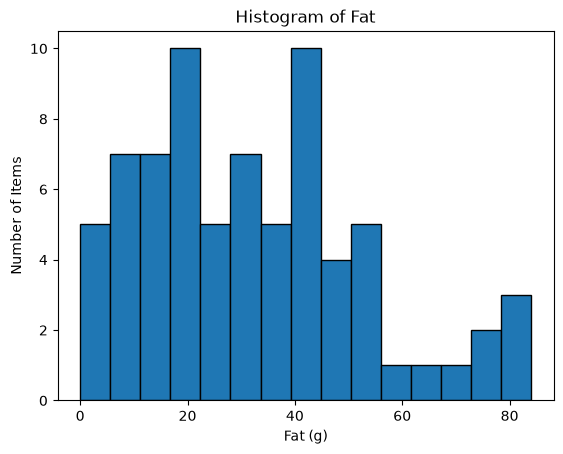

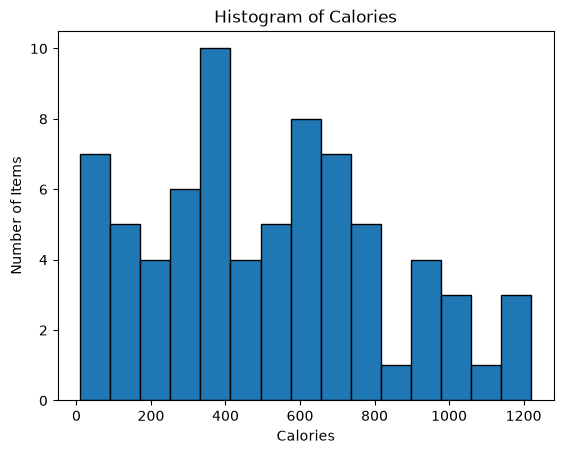

In [17]:
# Histogram of fat
plt.figure()
plt.hist(burger_king["Fat (g)"], bins=15, edgecolor="black")
plt.title("Histogram of Fat")
plt.xlabel("Fat (g)")
plt.ylabel("Number of Items")
plt.show()

# Histogram of calories
plt.figure()
plt.hist(burger_king["Calories"], bins=15, edgecolor="black")
plt.title("Histogram of Calories")
plt.xlabel("Calories")
plt.ylabel("Number of Items")
plt.show()

In [18]:
# Choose two features based on their correlation
corr_matrix = burger_king.select_dtypes(include="number").corr()
print(corr_matrix["Calories"].sort_values(ascending=False))

Calories             1.000000
Weight Watchers      0.999546
Fat (g)              0.979042
Fat Calories         0.978881
Protein (g)          0.912112
Saturated Fat (g)    0.875359
Sodium (mg)          0.854986
Total Carb (g)       0.783756
Cholesterol (mg)     0.706074
Trans Fat (g)        0.672546
Dietary Fiber (g)    0.462443
Sugars (g)           0.428076
Name: Calories, dtype: float64


In [19]:
X = np.c_[burger_king["Fat (g)"]]
y = np.c_[burger_king["Calories"]]

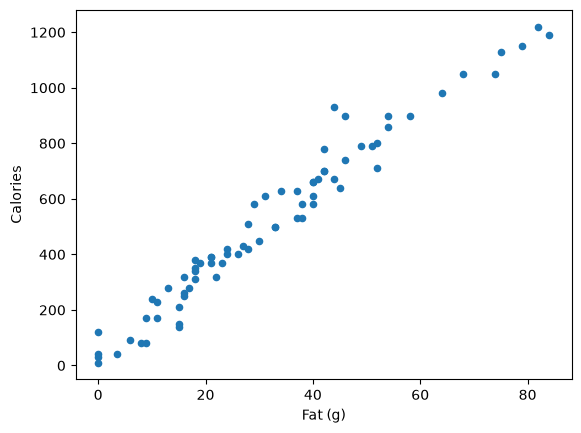

In [20]:
# Visualize the data
burger_king.plot(kind='scatter', x="Fat (g)", y="Calories")
plt.savefig("fat_vs_calories.png")
plt.show()

In [21]:
# Select a linear model
model = sklearn.linear_model.LinearRegression()

In [22]:
# Train the model
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[14.69]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[45.99]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[174.9]


In [23]:
# Get results from the trained model
print("Intercept:", model.intercept_)
print("Slope:", model.coef_)
print("R^2:", model.score(X, y))

#Fat explains about 96% of the variation in calories. Each extra gram of fat adds about 14.7 calories on average.

Intercept: [45.98804205]
Slope: [[14.69388431]]
R^2: 0.9585227944753614


In [24]:
# Make a prediction for a new item with 30 g of fat
X_new = [[30]]
print(model.predict(X_new))

[[486.80457146]]
